#**Exercises XP**

Exercise 1 : Small Quizz

Q1 — Différence ML vs Deep Learning

En ML classique, c'est toi qui choisis et construis les features (ex : "je prends la taille, l'âge, le revenu"). La machine apprend seulement à partir de ces features que tu lui donnes.
En Deep Learning, le réseau extrait lui-même les features couche par couche. Tu lui donnes juste les données brutes (une image, un texte, un son), et il apprend tout seul quoi regarder.

Q2 — Comment les ANN imitent le cerveau

Un neurone artificiel imite un neurone biologique : il reçoit des signaux (inputs), les pondère (weights), et transmet ou non un signal selon un seuil (fonction d'activation). Les neurones sont organisés en couches connectées, comme dans le cortex cérébral.


Q3 — Pourquoi DL performe mieux sur les grands datasets

le DL a des millions de paramètres (poids). Pour les ajuster correctement, il a besoin de beaucoup de données. Avec peu de données, le ML classique suffit et est même meilleur. Avec des millions d'exemples, le DL peut capturer des patterns très complexes que le ML classique ne peut pas voir.

Q4 — Les défis du Deep Learning

Les vrais défis du DL sont :

Besoin de beaucoup de données → solution : data augmentation, transfer learning
Coût de calcul élevé (GPU nécessaire) → solution : cloud computing (Google Colab)
Boîte noire (on ne comprend pas facilement pourquoi il décide) → solution : outils d'interprétabilité (SHAP, LIME)
Overfitting (il apprend par cœur sans généraliser) → solution : dropout, regularisation
Long à entraîner → solution : optimiseurs comme Adam

Q5 — Feature Engineering

Les features = les colonnes de ton dataset (taille, âge, revenu...).
Le feature engineering = le travail manuel de créer de nouvelles features utiles à partir des données brutes. Ex : à partir de la date de naissance, tu crées la colonne "âge". À partir du salaire et du loyer, tu crées "taux d'endettement".
En DL, ce travail n'est plus nécessaire parce que les couches cachées apprennent automatiquement ces représentations complexes. Le réseau "invente" lui-même ses propres features internes.

Q6 — Rôle des couches cachées

Chaque couche cachée apprend une représentation de plus en plus abstraite des données.

Couche 1 → détecte des patterns simples (ex : contours d'une image)
Couche 2 → combine ces patterns (ex : formes, angles)
Couche 3 → reconnaît des concepts (ex : "c'est une main", "c'est un chiffre 7")

C'est cette hiérarchie de représentations qui rend le DL si puissant.

Q7 — Fonction d'activation

Son rôle est d'introduire de la non-linéarité dans le réseau. Sans elle, empiler 100 couches donnerait le même résultat qu'une seule couche (tout resterait une simple multiplication de matrices).
Elle décide aussi si un neurone doit "s'activer" (envoyer un signal fort) ou non, selon le résultat qu'il reçoit.

Exercice 2 : Système de décision basé sur un Perceptron

In [1]:

def perceptron(temp, pluie, biais=2):
    """
    Détermine s'il faut sortir ou non selon la température et la pluie.
    - temp  : température en °F
    - pluie : 1 = il pleut, 0 = pas de pluie
    - biais : valeur par défaut = 2
    """
    # Calcul de la somme pondérée
    weighted_sum = (temp * 0.6) + (pluie * 0.4) + biais

    # Fonction d'activation (Step Function)
    if weighted_sum > 20:
        return 1  # Sortir
    else:
        return 0  # Rester à la maison

# Case 1 : Température = 70°F, Pas de pluie
resultat_1 = perceptron(70, 0)
print(f"Case 1 - Décision : {'Sortir ' if resultat_1 == 1 else 'Rester '}")

print()

#  Case 2 : Température = 50°F, Il pleut
resultat_2 = perceptron(50, 1)
print(f"Case 2 - Décision : {'Sortir ' if resultat_2 == 1 else 'Rester '}")

print(f"  Interprétation: \n Dans les deux cas, le perceptron recommande de sortir car les deux sommes pondérées dépassent largement le seuil de 20.")

print(f"Même sous la pluie (Case 2), la température reste suffisamment élevée pour influencer la décision, car son poids (0.6) est plus important que celui de la pluie (0.4). ")

Case 1 - Décision : Sortir 

Case 2 - Décision : Sortir 
  Interprétation: 
 Dans les deux cas, le perceptron recommande de sortir car les deux sommes pondérées dépassent largement le seuil de 20.
Même sous la pluie (Case 2), la température reste suffisamment élevée pour influencer la décision, car son poids (0.6) est plus important que celui de la pluie (0.4). 


Exercise 3 — Neural Network avec MNIST

In [2]:
#Importation

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
#Chargement du dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
#Normaliser les données (diviser par 255.0)
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-Hot Encoding des labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
#Construire le modèle
model = models.Sequential(
    [
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ]
)

In [ ]:
# Compiler le modele

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Entraîner
model.fit(x_train, y_train, epochs=5, batch_size=32)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9262 - loss: 0.2587
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9662 - loss: 0.1136
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9768 - loss: 0.0775
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9821 - loss: 0.0585
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9857 - loss: 0.0455


In [ ]:
# Évaluer
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Précision sur les données test : {accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9799 - loss: 0.0703
Précision sur les données test : 97.99%


Exercice 4 : Forward Propagation (calcul de prix de maison

In [ ]:
import numpy as np

# Données
x1 = 2000  # Superficie
x2 = 3     # Chambres

# Poids et biais
w1 = 0.5
w2 = 0.7
b = 50000

# Étape 1 : Calcul de z (somme pondérée)
z = (x1 * w1) + (x2 * w2) + b
print(f"z avant activation : {z}")

# Étape 2 : Appliquer ReLU
def relu(z):
    return max(0, z)

prediction = relu(z)
print(f"Prix prédit (après ReLU) : {prediction} $ \n")

print("Interpretation \n z avant activation : 51002.1")
print("Prix prédit (après ReLU) : 51002.1 $")

z avant activation : 51002.1
Prix prédit (après ReLU) : 51002.1 $ 

Interpretation 
 z avant activation : 51002.1
Prix prédit (après ReLU) : 51002.1 $


Exercice 5 (optionnel) : Forward + Backpropagation en Python

Le gradient indique la direction qui augmente l'erreur. En soustrayant le gradient, on va dans la direction opposée
On réduit l'erreur. C'est exactement ça, la descente de gradient.

Exercice 6 (optionnel) : Visualisation des prédictions MNIST

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9229 - loss: 0.2726 - val_accuracy: 0.9620 - val_loss: 0.1284
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9653 - loss: 0.1175 - val_accuracy: 0.9728 - val_loss: 0.0953
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9759 - loss: 0.0808 - val_accuracy: 0.9765 - val_loss: 0.0833
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9815 - loss: 0.0609 - val_accuracy: 0.9750 - val_loss: 0.0868
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9853 - loss: 0.0461 - val_accuracy: 0.9763 - val_loss: 0.0818
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


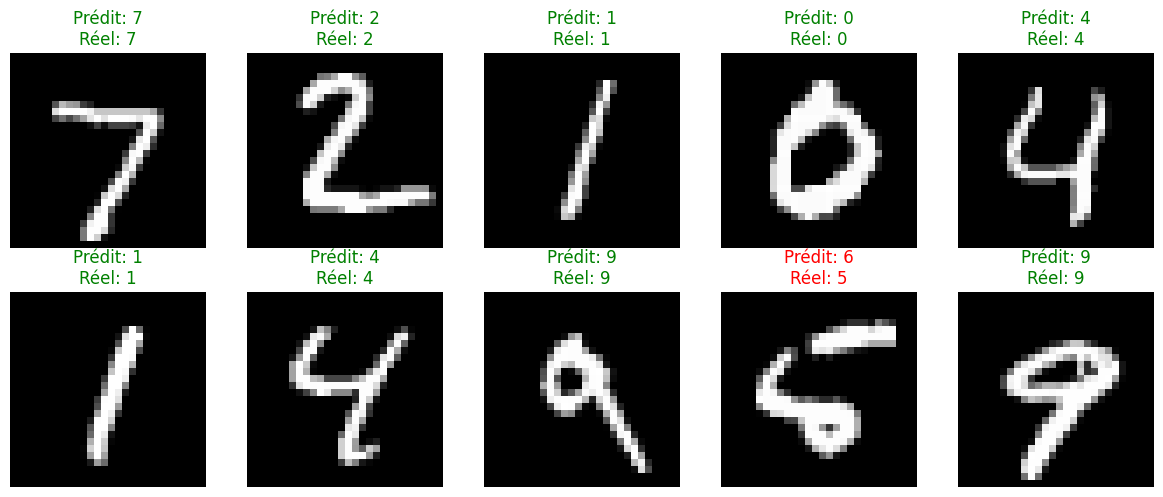

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

# 1. Charger les données
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Normaliser
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. One-Hot Encoding
y_train_encoded = to_categorical(y_train, 10)
y_test_encoded = to_categorical(y_test, 10)

# 4. Construire le modèle
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),  # 28×28 → 784 neurones
    layers.Dense(128, activation='relu'),  # Couche cachée
    layers.Dense(10, activation='softmax') # Sortie : 10 classes
])

# 5. Compiler
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Entraîner
model.fit(x_train, y_train_encoded, epochs=5, validation_split=0.1)

# 7. Prédictions
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
# argmax → prend l'indice du maximum dans le vecteur softmax

# 8. Visualiser
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_test[i], cmap='gray')
    ax.set_title(
        f"Prédit: {predicted_labels[i]}\nRéel: {y_test[i]}",
        color='green' if predicted_labels[i] == y_test[i] else 'red'
    )
    ax.axis('off')
plt.tight_layout()
plt.show()